# Language Modelling 2

My notes for the following videos by Andrej Karpathy:

- [_Building makemore Part 3: Activations & Gradients, BatchNorm_](https://www.youtube.com/watch?v=P6sfmUTpUmc)
- [_Building makemore Part 4: Becoming a Backprop Ninja_](https://www.youtube.com/watch?v=q8SA3rM6ckI)

We will try to get a better understanding of the elements of the model with which we are working and take measures to diagnose and optimize the shortcomings.

In [33]:
# BUILD AND SPLIT DATA

import torch
import torch.nn.functional as F

words = open('names.txt', 'r').read().splitlines()

# Get all possible characters and create char to int mapping
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

# Hyperparameters
n = 3 # context length
m = 10 # embedding dimension
k = 200 # hidden layer size

def build_dataset(words):
    block_size = n # context length
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X  = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [54]:
# BUILD NN

C = torch.randn((27, m))
W1 = torch.randn((m * n, k)) * (5/3) / ((m * n)**0.5)
# b1 = torch.randn(k) * 0.01
W2 = torch.randn(k, 27) * 0.01
b2 = torch.randn(27) * 0

bngain = torch.ones((1, k))
bnbias = torch.zeros((1, k))

bnmean_running = torch.zeros((1, k))
bnstd_running = torch.ones((1, k))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [56]:
# TRAINING

max_steps = 200000
sgd_batch_size = 32

# Keep track of learning rate performance and/or optimization
# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre

lri = []
lossi = []
stepi = []

for i in range(max_steps):
    # SGD batch selection
    ix = torch.randint(0, Xtr.shape[0], (sgd_batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # Forward Pass
    emb = C[Xb] # Input (32, 3, 2)
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1

    # Batch normalization
    mui = hpreact.mean(0, keepdim=True)
    sigmai = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - mui) / sigmai + bnbias

    # Update running statistics
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * mui
        bnstd_running = 0.999 * bnstd_running + 0.001 * sigmai
    
    h = torch.tanh(hpreact) # First layer output (32, 100)
    logits = h @ W2 + b2 # Second layer output (32, 27)
    loss = F.cross_entropy(logits, Yb) # this is the standard loss we have been using
    
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update using custom lr
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track lr stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

    if i % 10000 == 0:
        print(f"iter: {i}, loss: {loss.item()}")

iter: 0, loss: 3.274033308029175
iter: 10000, loss: 2.06318736076355
iter: 20000, loss: 2.1458277702331543
iter: 30000, loss: 1.8794584274291992
iter: 40000, loss: 1.9599295854568481
iter: 50000, loss: 2.194054365158081
iter: 60000, loss: 1.8652174472808838
iter: 70000, loss: 1.9995365142822266
iter: 80000, loss: 1.9554669857025146
iter: 90000, loss: 2.1398892402648926
iter: 100000, loss: 2.157989263534546
iter: 110000, loss: 2.0052483081817627
iter: 120000, loss: 1.8963183164596558
iter: 130000, loss: 2.0089564323425293
iter: 140000, loss: 2.2170660495758057
iter: 150000, loss: 1.8995085954666138
iter: 160000, loss: 2.3953726291656494
iter: 170000, loss: 1.8862040042877197
iter: 180000, loss: 1.9918044805526733
iter: 190000, loss: 2.4425861835479736


In [68]:
# EVALUATION

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070040225982666
val 2.110779047012329


In [69]:
# SAMPLING FROM THE MODEL

for _ in range(20):
    out = []
    context = [0] * n
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1 # + b1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out), end=' ')

jahmaira. arii. thanna. aziyany. klaniney. jase. claeleen. mayan. markhalyn. gabf. aizel. jakhiyah. jeneti. melizailes. ese. hen. aedrah. cilie. ayyah. mich. 

# Initialization

If parameters are initialized at random, the value of the loss function evaluated at these initial parameters is usually quite large. Ideally, the model to be initialized in a way such that the probablility distribution it outputs given any context is uniform. Because the model has not learned anything, its output should be equivalent to a random guess. Under this assumption, we would expect a loss of $L = \log 27 \approx 3.3$. In other words, we are aiming to remove the "hockey stick" appearance of the loss graph.

The first way to combat this is to set the biases of the output layer (i.e. logit layer) to zero to ensure zero mean. We can also scale the weights of this layer to ensure smaller variance, which will lead to a more uniform logit distribution. However, this multiplier must not be zero.

Another issue is that a lot of the values output by the first hidden layer are very close to 1 or -1. This is because $\tanh$ is a "squashing" function, which is to say that values $x$ with $|x| \ge 3$ have $|\tanh x| \approx 1$. Recall that $\frac{d}{d x} \tanh x = 1 - \tanh^2 x$, meaning these $x$ values have zero derivative and will effectively stop backpropagation through their respective neurons. In the plot below, neurons with $|\tanh x > 0.99|$ are coloured in white (x-axis), over a randomly selected 32 examples (y-axis), evaluated at a randomly initialized model with the modifications proposed above. An entirely white column means that the neuron corresponding to that column is "dead" and will not contribute any meaningful learning to the model. Similar issues still occur with other popular activation functions such as the ReLU and sigmoid functions.

<img 
    style="display: block; 
           margin-left: auto;
           margin-right: auto;
           width: 60%;"
    src="tanhissue.png" 
    alt="alpha">
</img>

A reasonable way to fix this is to simply reduce the variance of the values going into $\tanh$ and ensure they are somewhat centered. It is important to still retain a certain level of "entropy", hence these scaling values should not be chosen too small. Below is the same plot after this fix. The newly trained model achieves a loss of $L = 2.10$, an improvement over the previous model's loss of around $L = 2.17$.

<img 
    style="display: block; 
           margin-left: auto;
           margin-right: auto;
           width: 60%;"
    src="tanhfixed.png" 
    alt="alpha">
</img>

For large networks, it is not practical (or easy) to choose all these scaling factors by hand. This scaling factor has been well researched and documented and depends on the number of inputs to the neuron as well as the activation function itself. Historically, initialization was a precise processes, but recent innovations have simplified the task. Two factors govern the variance:

- The _gain_ $g$ of an activation function $\sigma$ has to do with how variance scales when $N(0, 1)$ is transformed by $\sigma$. 
- The _fan in_ $n$ is the number of inputs to the neuron.

Assuming the inputs $\mathbf{x}$ to the neuron are already normally distributed with variance 1 and bias roughly 0, this gives

$$
    \text{Var}(\sigma(\mathbf{w}^T \mathbf{x})) \approx g^{-2} \cdot \text{Var}(\mathbf{w}^T \mathbf{x}) \approx n \cdot \text{Var}(w).
$$
Since we desire the left hand side to be one, we must set the variance of the weights to be $g^2/n$, i.e. divide by $g/ \sqrt n$.


## Batch Normalization

Among these recent developments, _batch normalization_ was introduced in 2015 and greatly improved the reliability of training. The idea behind batch normalization is to normalize the input $\mathbf{x}$ to a given layer using the component-wise sample mean $\mu_i$ and sample variance $s_i$ across the SGD batch. Hence, if pre-activation values for a given layer across a batch are $\mathbf{x}^{(1)}, ..., \mathbf{x}^{(b)}$, we compute a normalized vector

$$
    \hat{x}^{(k)}_i = \frac{x^{(k)}_i - \mu_i}{s_i}.
$$
However, forcing every layer to output pre-activation values with zero mean and unit variance can be overly restrictive. Thus, we introduce a scaling $\gamma_i$ and a shift $\beta_i$ for every neuron in the layer. The final pre-activation value for the $i$'th neuron on the $k$'th training example is given by 

$$
    z_i = \gamma_i \hat{\mathbf{x}}^{(k)}_i + \beta_i.
$$
Setting $\gamma_i = 1$ and $\beta_i = 0$ across the layer at initialization ensures that the input to the layer is standard gaussian on the first iteration of SGD, which is desired for the reasons discussed above. This is an improvement over manual scaling.

A desirable consequence of batch normalization is that it adds entropy to any specific training example within a batch. Because the input to the activation function now depends on statistics calculated from the entire batch, there is an added randomness due to the potential inaccuracy of the sample statistics. Intuitively, this lightly forces the model to learn true patterns as opposed to memorizing fragile patterns. This is a form of _regularization_ and is desirable in the training of a model.

Now that the forward pass depends on the batch, it is important to work out a way to be able to sample from this model on a single input. For this, we calculate the mean and standard deviation of the entire training set, and normalize the single sample using these statistics. In practice, these are calculated during training.

Finally, note that the bias for a batch normalized layer is no longer needed, since the normalization will completely negate this bias. In a sense, the $beta_i$ term "takes over" the role of the usual bias term for this neuron.


In [140]:
# ABSTRACT LAYERS

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Evaluate layer on x
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # Normalize and scale
        xhat = (x - mean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # Update running mean and var
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.mometum) * self.running_var + self.momentum * xvar
                
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
        
    def parameters(self):
        return []

46497


In [144]:
# BUILD MODEL

vocab_size = 27
block_size = 3
n_embd = 10
n_hidden = 100

C = torch.randn((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # Make logits less extreme, i.e. output more uniform
    layers[-1].weight *= 0.1
    # Apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print("model size:", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

model size: 46497


In [141]:
# OPTIMIZATION

# Same as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Construct minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Stats
    if i % 10000 == 0:
        print(f'{i}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

0: 3.2935


layer 1 (      Tanh): mean +0.03, std 0.72, saturated: 15.28%
layer 3 (      Tanh): mean +0.01, std 0.67, saturated: 7.78%
layer 5 (      Tanh): mean +0.01, std 0.66, saturated: 6.47%
layer 7 (      Tanh): mean +0.02, std 0.66, saturated: 6.66%
layer 9 (      Tanh): mean +0.00, std 0.66, saturated: 6.53%


Text(0.5, 1.0, 'activation distribution')

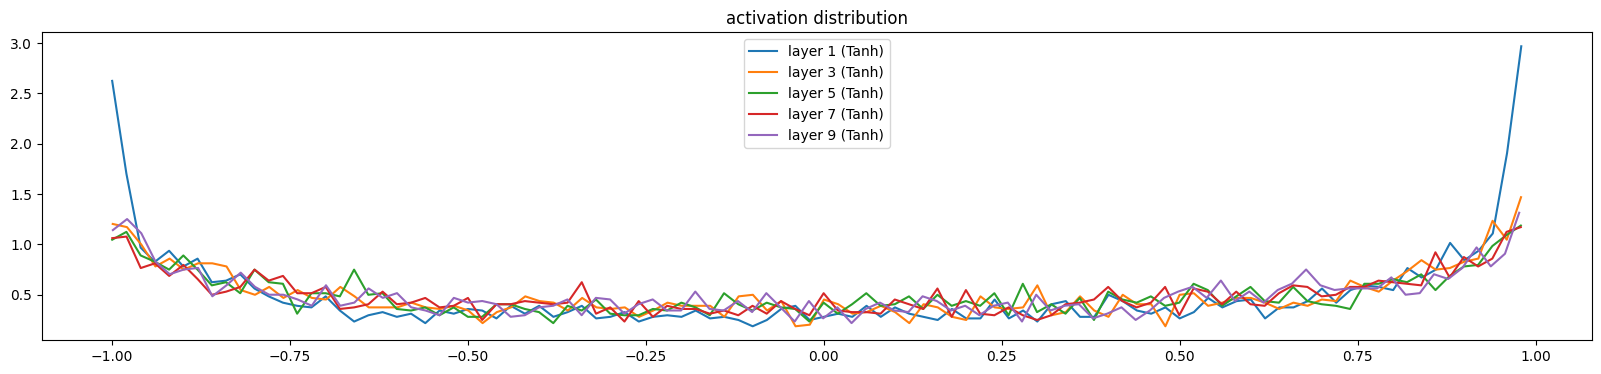

In [142]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % 
              (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).detach().float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

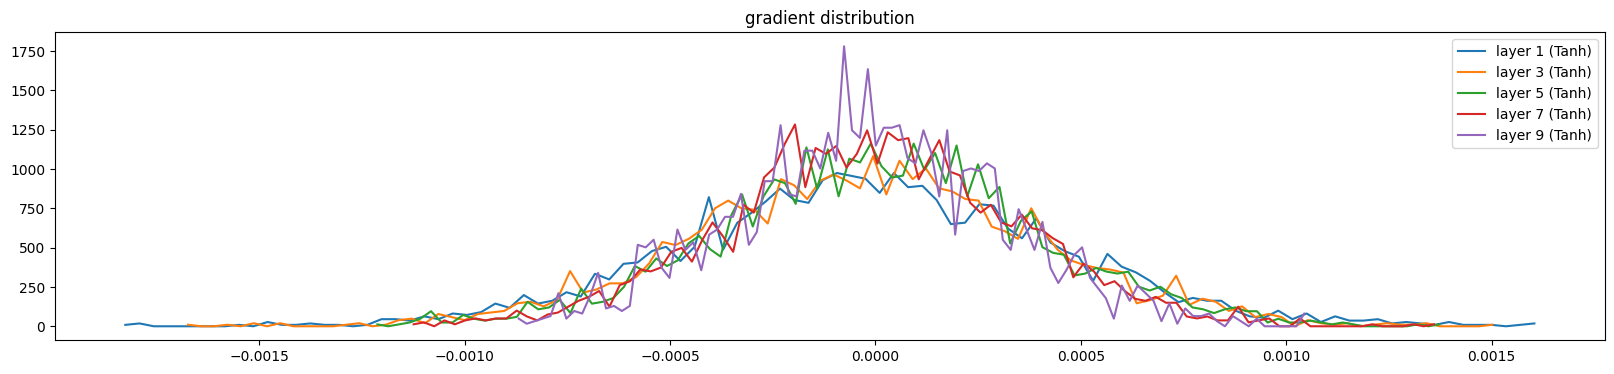

In [143]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % 
              (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).detach().float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('gradient distribution')

## Understanding Backpropagation

Before the release of PyTorch and similar autograd engines, backpropagation was implemented manually. While it is no longer an issue, it is important to understand the implementation of backpropagation on a tensor level. Below is an implementation of manual backpropagation at three levels of abstraction. In general, this is an exercise in calculus all while being careful about tensor dimensions and broadcasting rules. This can be usually done by deducing the form of a final answer using simple calculus and working out the details so that the tensor dimensions are consistent.

- Derivation of backpropagation for cross_entropy, batchnorm, linear

In [145]:
# UTILITY FUNCTION

def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [166]:
# BUILD MODEL

n_embd = 10
n_hidden = 64

# Here, to avoid a major simplification of the intial gradient, we add some randomness
C = torch.randn((vocab_size, n_embd))
W1 = torch.randn((n_embd * block_size, n_hidden))
b1 = torch.randn(n_hidden) # Useless because of BN but just for fun
W2 = torch.randn(n_hidden, vocab_size)
b2 = torch.randn(vocab_size)
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

4137


In [167]:
# FORWARD PASS

batch_size = 32
n = batch_size # shorter name
ix = torch.randint(0, Xtr.shape[0], (batch_size,))
Xb, Yb = Xtr[ix], Ytr[ix]

# Embedding
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)

# Linear layer 1
hprebn = embcat @ W1 + b1

# BatchNorm
bnmeani = 1/n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1) * (bndiff2).sum(0, keepdim=True)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# Non-linearity
h = torch.tanh(hpreact)

# Linear layer 2
logits = h @ W2 + b2

# Cross entropy loss
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum ** -1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

In [168]:
# PYTORCH BACKWARD PASS

# PyTorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(10.7928, grad_fn=<NegBackward0>)

In [213]:
# EXERCISE 1: Piece by piece

# loss = -logprobs[range(n), Yb].mean()
dlogprobs = torch.zeros_like(logprobs) # -1/n in indexed locations, 0 elsewhere
dlogprobs[range(n), Yb] = -1.0/n

# logprobs = probs.log()
dprobs = (1.0 / probs) * dlogprobs

# probs = counts * counts_sum_inv
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # recall broadcasting rules
dcounts = counts_sum_inv * dprobs

# counts_sum_inv = counts_sum ** -1
dcounts_sum = (- counts_sum ** -2) * dcounts_sum_inv

# counts_sum = counts.sum(1, keepdims=True)
dcounts += torch.ones_like(counts) * dcounts_sum

# counts = norm_logits.exp()
dnorm_logits = counts * dcounts

# norm_logits = logits - logit_maxes
dlogits = dnorm_logits.clone()
dlogit_maxes = -dnorm_logits.sum(1, keepdim=True) # in theory this should be 0

# logit_maxes = logits.max(1, keepdim=True).values
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

# logits = h @ W2 + b2
dh = dlogits @ W2.T # can figure this out using either matrix multiplication or using dimensions
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

# h = torch.tanh(hpreact)
dhpreact = (1.0 - h**2) * dh

# hpreact = bngain * bnraw + bnbias
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnbias = dhpreact.sum(0, keepdim=True)
dbnraw = bngain * dhpreact

# bnraw = bndiff * bnvar_inv
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)

# bnvar_inv = (bnvar + 1e-5)**-0.5 
dbnvar = -0.5 * (bnvar + 1e-5) ** -1.5 * dbnvar_inv

# bnvar = 1/(n-1) * (bndiff2).sum(0, keepdim=True)
dbndiff2 = 1.0/(n-1) * torch.ones_like(dbnvar) * dbnvar

# bndiff2 = bndiff**2
dbndiff +=  2 * bndiff * dbndiff2

# bndiff = hprebn - bnmeani
dhprebn = dbndiff.clone()
dbnmeani = -dbndiff.sum(0)

# bnmeani = 1/n * hprebn.sum(0, keepdim=True)
dhprebn += 1.0/n * torch.ones_like(dbnmeani) * dbnmeani

# hprebn = embcat @ W1 + b1
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

# embcat = emb.view(emb.shape[0], -1)
demb = dembcat.view(emb.shape)

# emb = C[Xb]
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k, j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts', dcounts, counts)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [211]:
# EXERCISE 2: cross_entropy

loss_fast = F.cross_entropy(logits, Yb)

# An exercise in calculus
dlogits = F.softmax(logits, 1) 
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09


In [214]:
# EXERCISE 3: BatchNorm

# Use calculus and backpropagate component-wise from x hat. Helps to draw a diagram.
dhprebn = bngain * bnvar_inv / n * (n*dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
